<a href="https://colab.research.google.com/github/glorenz1/MSE_Spring_2026/blob/main/Homework_4_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Homework 4 for the MSE510/420 Course
- Instructor Sergei V. Kalinin, sergei2@utk.edu
- Please provide your name in the beginning of the notebook
- To submit the homework, please share it with my gmail address (available on Canvas)

- Run the code cell below
- If the gdown does not work due to too many requests, use the file hw3.zip on course GitHub page

In [ ]:
!gdown https://drive.google.com/uc?id=1UC6bu5nVFRBhHIL698jk0zt3AuDqREkV
!unzip hw3.zip

Downloading...
From: https://drive.google.com/uc?id=1UC6bu5nVFRBhHIL698jk0zt3AuDqREkV
To: /content/hw3.zip
100% 9.96k/9.96k [00:00<00:00, 30.0MB/s]
Archive:  hw3.zip
  inflating: hw3p1.csv               
  inflating: hw3p2.csv               
  inflating: hw3p3.csv               


Now you have created 3 csv files, named hw3p1, hw3p2, and hw3p3 respectively. Load the file hw3p1 into Pandas DataFrame. It will contain three sets of data representing x and corresponding f(x). There are three sets of data overall.

Problem 1. Fit the first set of data. Please try to find equation that can explain whole data set (not spline)

In [ ]:
!pip install pysr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 13.0 MB/s eta 0:00:00


In [ ]:
from pysr import PySRRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/pysr/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliapkg/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] Using Julia 1.11.5 at /usr/local/bin/julia
[juliapkg] Using Julia project at /root/.julia/environments/pyjuliapkg
[juliapkg] Writing Project.toml:
           | [deps]
           | SymbolicRegression = "8254be44-1295-4e6a-a16d-46603ac705cb"
           | Serialization = "9e88b42a-f829-5b0c-bbe9-9e923198166b"
           | PythonCall = "6099a3de-0909-46bc-b1f4-468b9a2dfc0d"
           | OpenSSL_jll = "458c3c95-2e84-50aa-8efc-19380b2a3a95"
           | 
           | [compat]
           | SymbolicRegression = "~1.11"
           | Serialization = "^1"
           | PythonCall = "=0.9.26"
           | OpenSSL_jll = "~3.0"
[juliapkg] Installing packages:
           | impo

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.330e+05
Progress: 743 / 1000 total iterations (74.300%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.890e+01  0.000e+00  y = 8.2558
3           1.196e+01  2.287e-01  y = x₀ + 3.3063
4           9.744e+00  2.049e-01  y = sqrt(x₀ / 0.064035)
6           2.419e+00  6.966e-01  y = x₀ + (0.078199 ^ sin(x₀))
7           1.435e+00  5.222e-01  y = exp(0.39768 ^ sin(x₀)) + x₀
8           1.302e+00  9.743e-02  y = (0.089105 ^ sin(x₀)) + (x₀ + 1.1667)
9           1.275e+00  2.117e-02  y = (exp(0.38401 ^ sin(x₀)) + x₀) / 1.0569
10          1.155e+00  9.893e-02  y = (x₀ + 0.93373) + (0.090495 ^ sin(x₀ ^ 0.98829))
11          5.749e-01  6.973e-01  y = exp(sin((x₀ + -2.0959) * 0.6054) * 2.3681) + x₀
12          2.894e-01  6.863e-01  y = (exp(sin(0.34621 *

[ Info: Final population:
[ Info: Results saved to:


Best equation:  x0 + exp(sin(0.34620938*x0))**(1.4391435 - sin(x0))


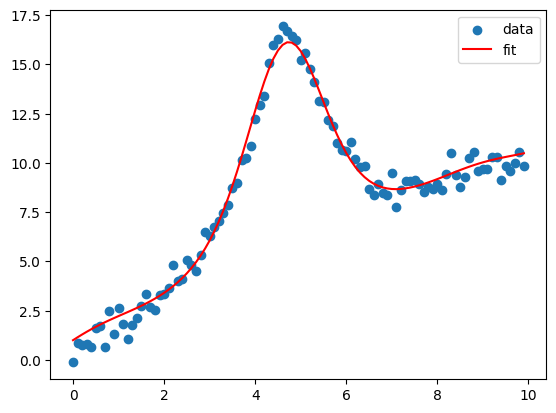

  - outputs/20260312_145008_S0H8po/hall_of_fame.csv


In [ ]:
hw3p1 = pd.read_csv('hw3p1.csv')

def pysr (df, x_col, y_col):
  x = df[x_col].values
  y = df[y_col].values

  model = PySRRegressor(
      niterations=100,
      binary_operators=["+", "-", "*", "/", "^"],
      unary_operators=[
        "sin", "cos", "exp", "log", "sqrt"
      ],
      maxsize=15,
      populations=10,
  )
  model.fit(x, y)
  return model

model = pysr(hw3p1, ["x"], "y")

print("Best equation: ", model.sympy())

x = hw3p1[["x"]].values
y = hw3p1["y"].values

yfit = model.predict(x)

plt.scatter(x, y, label="data")
plt.plot(x, yfit, color="red", label="fit")
plt.legend()
plt.show()

Problem 2. Fit the second set of data.  Please try to find equation that can explain whole data set (not spline)


Expressions evaluated per second: 1.290e+05
Progress: 750 / 1000 total iterations (75.000%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.054e+01  0.000e+00  y = x₀
3           4.744e+00  1.273e+00  y = x₀ ^ 1.4159
5           2.196e+00  3.852e-01  y = (x₀ ^ 1.9337) * 0.34125
9           2.077e+00  1.386e-02  y = log(exp(x₀ ^ 1.5865) + 2.4473) - x₀
10          7.709e-01  9.912e-01  y = (sin(x₀ * 3.0906) + (x₀ ^ 1.5882)) - x₀
11          7.709e-01  2.623e-06  y = sin(x₀ * 3.0907) + ((x₀ ^ sqrt(2.5225)) - x₀)
12          7.708e-01  1.751e-04  y = sin(x₀ * 3.0909) + ((x₀ ^ 1.5878) - (x₀ + -0.020733))
14          7.217e-01  3.290e-02  y = log(exp((x₀ ^ 1.5882) - x₀) + 0.69035) + sin(x₀ * 3.09...
                                      06)
15          3.285e-01  7.870e-01  y = ((sin(

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


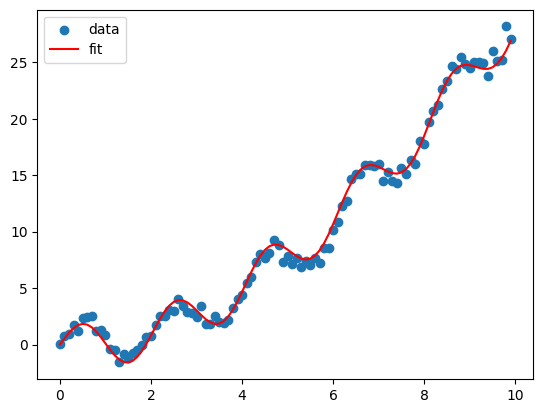

  - outputs/20260312_145034_K23A6H/hall_of_fame.csv


In [ ]:
model = pysr(hw3p1, ["x.1"], "y.1")
print("Best equation: ", model.sympy())

x = hw3p1[["x.1"]].values
y = hw3p1["y.1"].values

yfit = model.predict(x)

plt.scatter(x, y, label="data")
plt.plot(x, yfit, color="red", label="fit")
plt.legend()
plt.show()

Problem 3. Fit the third set of data.  Please try to find equation that can explain whole data set (not spline)

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.062e+00  0.000e+00  y = x₀
3           2.968e+00  1.566e-02  y = x₀ + 0.30733
4           2.563e+00  1.467e-01  y = x₀ - sin(x₀)
6           2.319e+00  4.999e-02  y = (x₀ - sin(x₀)) + 0.4938
7           1.694e+00  3.140e-01  y = (0.11937 / sin(exp(x₀))) + x₀
8           3.816e-01  1.491e+00  y = (0.11937 / (sin(x₀) + 1.0112)) + x₀
10          3.311e-01  7.096e-02  y = ((0.11937 / (sin(x₀) + 1.0112)) + x₀) + -0.22002
11          2.887e-01  1.371e-01  y = (x₀ + -0.56943) + (0.48969 / sqrt(sin(x₀) + 1.0011))
13          2.671e-01  3.873e-02  y = (x₀ - 1.2713) + sqrt((0.43047 / (sin(x₀) + 1.0023)) + ...
                                      0.93555)
───────────────────────────────────────────────────────────────────────────────────────────────────
Best equation:  x0 + 0.11937104/(sin(x0) + 1.0112293)


[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


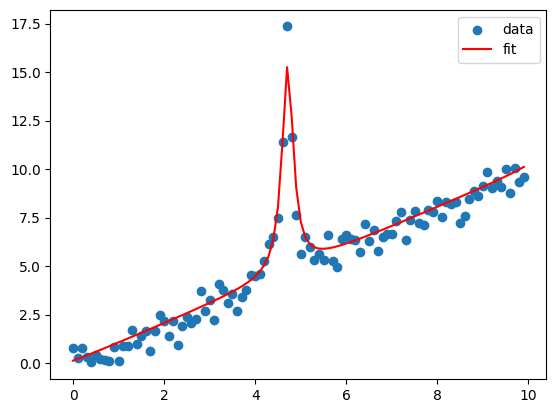

  - outputs/20260312_145041_pdzMUn/hall_of_fame.csv


In [ ]:
model = pysr(hw3p1, ["x.2"], "y.2")
print("Best equation: ", model.sympy())

x = hw3p1[["x.2"]].values
y = hw3p1["y.2"].values

yfit = model.predict(x)

plt.scatter(x, y, label="data")
plt.plot(x, yfit, color="red", label="fit")
plt.legend()
plt.show()

Load the file hw3p2 into Pandas DataFrame. It will contain values of x, y, and f = f(x,y)

Problem 4: Fit f(x,y).  Please try to find equation that can explain whole data set (not spline)

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.179e-02  0.000e+00  y = 0.1337
5           2.832e-02  9.731e-02  y = exp(x₀ - exp(x₀))
6           2.694e-02  4.980e-02  y = (cos(x₁) * 0.1731) + 0.15501
7           2.685e-02  3.316e-03  y = 0.15686 + (0.17586 * sin(cos(x₁)))
8           5.693e-03  1.551e+00  y = exp(x₀ - (exp(x₀) - cos(x₁)))
9           5.545e-03  2.622e-02  y = sin(exp(x₀ - (exp(x₀) - cos(x₁))))
10          2.048e-03  9.959e-01  y = exp(x₀ - (exp(x₀) - cos(x₁))) ^ 1.3138
12          1.295e-03  2.291e-01  y = exp(x₀ - (exp(x₀ - 0.11431) - cos(x₁))) ^ 1.4318
13          1.111e-03  1.540e-01  y = sin(exp(x₀ - (exp(x₀ + -0.19983) - cos(x₁))) ^ 1.4812)
───────────────────────────────────────────────────────────────────────────────────────────────────
Best equation:  exp(x0 - (exp(x0 - 1*0.11431344) - cos(x1)))**1.4318122


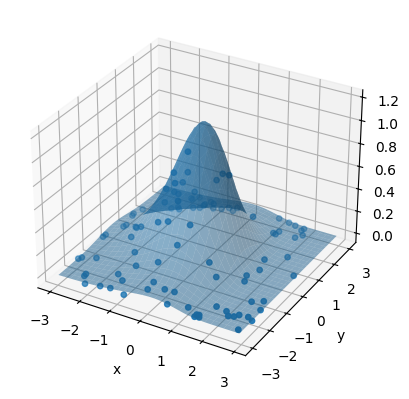

  - outputs/20260312_145046_VxXhD7/hall_of_fame.csv


In [ ]:
hw3p2 = pd.read_csv('hw3p2.csv')

model = pysr(hw3p2, ["x","y"], "z")
print("Best equation: ", model.sympy())

x = hw3p2["x"].values
y = hw3p2["y"].values
z = hw3p2["z"].values

gx = np.linspace(x.min(), x.max(), 60)
gy = np.linspace(y.min(), y.max(), 60)
Xg, Yg = np.meshgrid(gx, gy)
XYg = np.c_[Xg.ravel(), Yg.ravel()]

Zg = model.predict(XYg).reshape(Xg.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x, y, z, s=15, label="data")
ax.plot_surface(Xg, Yg, Zg, alpha=0.5)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.show()

Load the file hw3p3 into Pandas DataFrame. It will contain values of x1, x2, and y.  

Problem 5: Explore the relationships between y and x2, y and x1, and y(x1,x2). Make you guesses about how this data was generated.

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:96: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.893e-01  0.000e+00  y = 0.063644
3           4.582e-02  1.070e+00  y = 0.0039018 - x₁
5           2.063e-02  3.989e-01  y = x₀ - (x₁ + x₁)
7           1.193e-02  2.740e-01  y = ((x₀ - x₁) * 3.0271) - x₀
8           1.192e-02  6.669e-04  y = sin((x₀ - x₁) * 2.0624) - x₁
9           1.192e-02  4.718e-04  y = (((x₀ - x₁) * 2.027) - x₁) + 0.0036902
10          1.185e-02  5.254e-03  y = ((x₀ - x₁) * (2.8489 - cos(x₁))) - x₁
11          1.173e-02  1.031e-02  y = ((3.0527 - (x₀ * -0.26718)) * (x₀ - x₁)) - x₀
12          1.108e-02  5.679e-02  y = sin((3.0341 - (0.010271 / x₁)) * (x₀ - x₁)) - x₀
14          1.099e-02  4.318e-03  y = ((x₀ - x₁) * (3.7621 - cos(x₁ - (-0.031055 / x₁)))) - ...
                                      x₀
15          1.096e-02  2.899e-03  y = ((3.7621 - sin(exp((-0.031055 / x₁) - x₁))) * (x₀ - x₁...
                

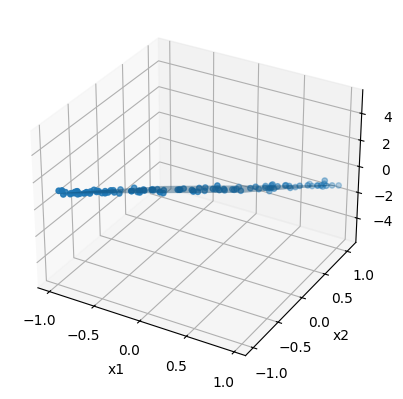

  - outputs/20260312_145051_AORG5C/hall_of_fame.csv


In [ ]:
hw3p3 = pd.read_csv('hw3p3.csv')

model = pysr(hw3p3, ["x1","x2"], "y")
print("Best equation: ", model.sympy())

x1 = hw3p3["x1"].values
x2 = hw3p3["x2"].values
y  = hw3p3["y"].values


g1 = np.linspace(x1.min(), x1.max(), 60)
g2 = np.linspace(x2.min(), x2.max(), 60)
X1g, X2g = np.meshgrid(g1, g2)
Xg = np.c_[X1g.ravel(), X2g.ravel()]


Yg = model.predict(Xg).reshape(X1g.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x1, x2, y, s=15, label="data")
ax.plot_surface(X1g, X2g, Yg, alpha=0.5)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")
plt.show()

Relationship between y and x1:
The plot of y versus x1 shows a strong positive linear relationship. As x1 increases, y increases in a nearly straight line pattern. This indicates that x1 contributes positively and linearly to y. The symbolic regression result confirms this, with a coefficient of about +2 multiplying x1.

Relationship between y and x2:
The plot of y versus x2 shows a strong negative linear relationship. As x2 increases, y decreases in a straight-line pattern. This means x2 contributes negatively and linearly to y. The regression equation shows a coefficient of about −3 multiplying x2.

Relationship between y(x1, x2):
When both variables are considered together, the data forms a plane in three-dimensional space. This means y depends on a linear combination of x1 and x2. The symbolic regression equation y ≈ 2.027·x1 − 3.027·x2 shows that both variables contribute independently and linearly.

Likely data generation method:
The data was most likely generated using a simple linear function of the form y = 2(x1) − 3(x2). The coefficients found by symbolic regression are very close to these values, suggesting the dataset was intentionally created using this linear relationship, possibly with small rounding effects.

Problem 6: Using ChatGPT, explore the the connection between the evolution of specific areas in physics and the development of special functions. Feel free to choose your own area, or pick one from the list below

1. Quantum Mechanics and Hermite Polynomials
Problem: Investigate the role of Hermite polynomials in the formulation of quantum mechanics. Discuss how these special functions contribute to the solutions of the quantum harmonic oscillator and their implications for understanding quantum states.

2. General Relativity and Legendre Functions
Problem: Explore the use of Legendre functions in the context of general relativity, particularly in solving the Schwarzschild solution. Analyze how these functions help describe the curvature of spacetime around spherical masses.

3. Electromagnetism and Spherical Harmonics
Problem: Study the application of spherical harmonics in solving Maxwell's equations in spherical coordinates. Discuss the significance of these special functions in understanding electromagnetic fields and potentials.

4. Fluid Dynamics and Bessel Functions
Problem: Examine how Bessel functions are utilized in fluid dynamics, especially in problems involving cylindrical symmetry. Evaluate their role in modeling flow in pipes and around obstacles.

5. Statistical Mechanics and Laguerre Polynomials
Problem: Explore the application of Laguerre polynomials in statistical mechanics, focusing on their role in the distribution functions of ideal quantum gases. Analyze how these functions aid in deriving properties like pressure and energy density.

6. Astrophysics and Associated Legendre Functions
Problem: Investigate the significance of associated Legendre functions in astrophysics, particularly in modeling gravitational potentials and describing the shapes of rotating astronomical bodies.

You can:
- Begin with a brief overview of the selected area of physics and its fundamental questions or problems.
- Use ChatGPT to explore how special functions were introduced to address specific challenges in that area.
- Analyze the mathematical properties of the special functions and how they contribute to the solutions of physical problems.
- Discuss the broader implications of these solutions for the field of physics and our understanding of the universe.
- What are your thoughts on interplay between mathematical innovation and physical discovery? how advances in one domain can spur progress in the other?

Answer 6:

Quantum mechanics was developed to explain physical phenomena that classical physics could not, such as atomic energy levels and particle behavior. One of the most important systems in quantum mechanics is the quantum harmonic oscillator, which describes vibrating particles, atoms, and electromagnetic field modes. Solving the Schrodinger equation for this system leads to a differential equation whose solutions involve Hermite polynomials.

Hermite polynomials appear naturally in the wavefunctions of the quantum harmonic oscillator. The solutions take the form of a Gaussian function multiplied by a Hermite polynomial. These polynomials ensure that the wavefunctions remain finite and physically meaningful. Their mathematical properties, such as orthogonality and discrete order, directly explain why quantum systems have discrete energy levels. Each Hermite polynomial corresponds to a specific quantum state and energy level.

This connection helps explain fundamental features of quantum mechanics, including quantization and the structure of quantum states. The harmonic oscillator model is also important in many areas of physics, including molecular vibrations, solid-state physics, and quantum field theory.

This example demonstrates the strong relationship between mathematics and physics. Hermite polynomials were originally studied as abstract mathematical objects, but later became essential for describing real physical systems. At the same time, the needs of physics helped drive the development of new mathematical methods. This shows that advances in mathematics and physics often support and accelerate each other, leading to deeper understanding of the universe.